In [6]:
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn
# !pip install umap-learn
# !pip install plotly
# !pip install scipy
!pip install kneed

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
from scipy.cluster.hierarchy import dendrogram, linkage

In [8]:
from sklearn.decomposition import PCA

In [9]:
# 1. Load Data
df = pd.read_csv('/content/fertilizer_recommendation.csv')
df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)

In [10]:
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


In [11]:
# ==============================================================================
# TAHAP 2: PREPROCESSING (Mengubah Teks Menjadi Angka & Menyamakan Skala)
# ==============================================================================


# 1. Hapus kolom target ('Recommended_Fertilizer') karena ini Unsupervised
X = df[['Temperature', 'Humidity']]

# 4. Samakan skala angka (Scaling) agar algoritma tidak bingung
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# ==============================================================================
# TAHAP 3: EVALUASI (Mencari Jumlah Klaster / K Terbaik)
# ==============================================================================
print("Tahap 3: Mencari Nilai K Optimal...")

# A. Menggunakan Elbow Method
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans_test.fit(X_scaled)
    wcss.append(kmeans_test.inertia_)

# B. Mencari patahan ("siku") secara otomatis menggunakan KneeLocator
kl = KneeLocator(list(K_range), wcss, curve="convex", direction="decreasing")
k_optimal = kl.elbow

# # Jika siku tidak ditemukan secara otomatis, kita beri nilai default 3
# if k_optimal is None:
#     k_optimal = 3

print(f">>> Hasil Deteksi Elbow: K = {k_optimal}")

Tahap 3: Mencari Nilai K Optimal...
>>> Hasil Deteksi Elbow: K = 4


In [13]:
# C. Menggunakan Silhouette Score
silhouette_scores = []
for k in range(2, 11):
    kmeans_sil = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans_sil.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

best_k_sil = range(2, 11)[np.argmax(silhouette_scores)]
print(f">>> Hasil Deteksi Silhouette: K = {best_k_sil}")

>>> Hasil Deteksi Silhouette: K = 4



Tahap 4: Menjalankan K-Means Final dengan K=4...


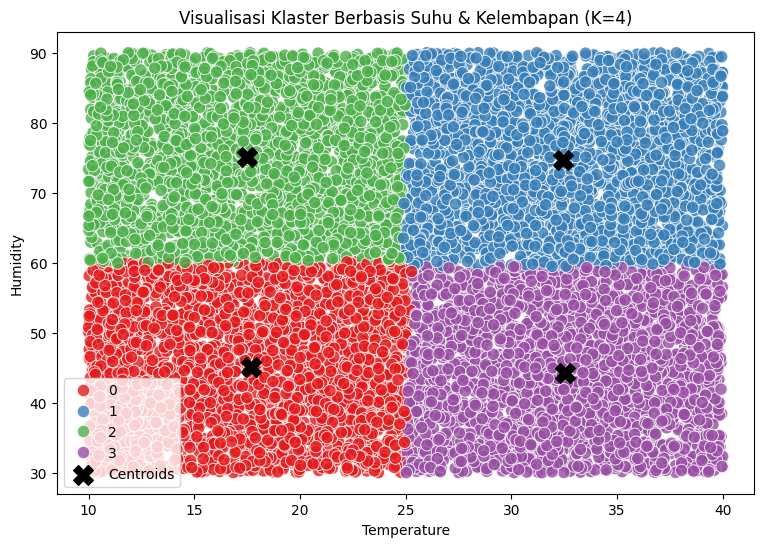

In [14]:
# ==============================================================================
# TAHAP 4: K-MEANS FINAL & VISUALISASI SEDERHANA
# ==============================================================================
print(f"\nTahap 4: Menjalankan K-Means Final dengan K={k_optimal}...")

kmeans_final = KMeans(n_clusters=k_optimal, n_init='auto', random_state=42)
df['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Temperature',
    y='Humidity',
    hue='Cluster_KMeans',
    palette='Set1',
    s=80,
    alpha=0.8
)

# Plot Centroid (titik pusat klaster)
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    marker='X', s=200, c='black', label='Centroids'
)

plt.title(f"Visualisasi Klaster Berbasis Suhu & Kelembapan (K={k_optimal})")
plt.legend()
plt.show()


Tahap 5: Menjalankan Agglomerative Clustering...


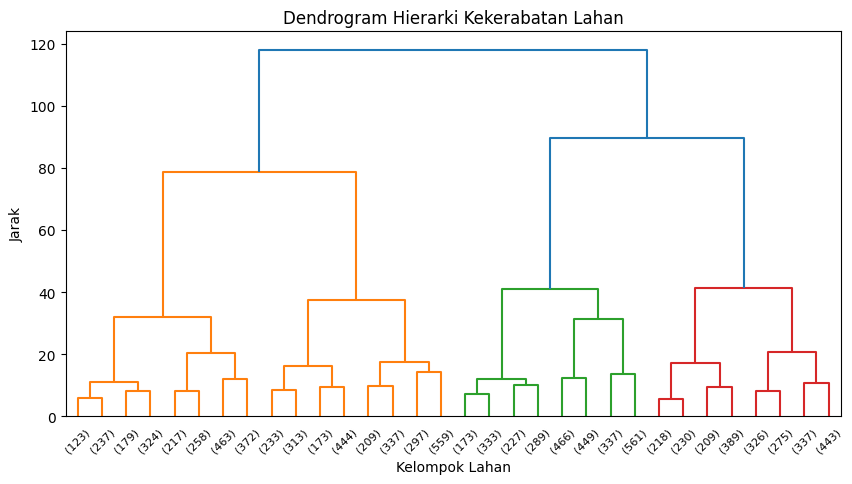


=== RATA-RATA KARAKTERISTIK SETIAP KLASTER UNTUK LAPORAN ===
                Temperature  Humidity  Soil_Moisture  Soil_pH  Nitrogen_Level
Cluster_KMeans                                                               
0                     17.66     45.20          35.45     6.47           87.25
1                     32.44     74.64          35.13     6.49           88.91
2                     17.49     75.18          35.42     6.49           89.42
3                     32.52     44.28          35.67     6.49           90.41


In [15]:
# ==============================================================================
# TAHAP 5: AGGLOMERATIVE & EKSTRAKSI HASIL
# ==============================================================================
print("\nTahap 5: Menjalankan Agglomerative Clustering...")

# 1. Membuat Dendrogram (Menggunakan sebagian data agar cepat)
X_dendro = X_scaled[:10000]
linkage_matrix = linkage(X_dendro, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode='level', p=4)
plt.title('Dendrogram Hierarki Kekerabatan Lahan')
plt.xlabel("Kelompok Lahan")
plt.ylabel("Jarak")
plt.show()

# 2. Menerapkan Agglomerative
model_agglo = AgglomerativeClustering(n_clusters=k_optimal, linkage='ward')
df["Cluster_Agglo"] = model_agglo.fit_predict(X_scaled)

# 3. Menampilkan Ringkasan Karakteristik (Untuk Laporan)
kolom_penting = ['Temperature', 'Humidity', 'Soil_Moisture', 'Soil_pH', 'Nitrogen_Level']
ringkasan = df.groupby('Cluster_KMeans')[kolom_penting].mean().round(2)

print("\n=== RATA-RATA KARAKTERISTIK SETIAP KLASTER UNTUK LAPORAN ===")
print(ringkasan)

Klaster, Suhu (Temp), Kelembapan (Hum), Interpretasi Lahan

0, 17.66, 45.20, Lahan Dingin & Kering

1, 32.44, 74.64, Lahan Panas & Lembap (Tropis Basah)

2, 17.49, 75.18, Lahan Dingin & Lembap (Daerah Pegunungan)

3, 32.52, 44.28, Lahan Panas & Kering (Lahan Terik)

In [16]:
import joblib

# Menyimpan model K-Means yang sudah dilatih
joblib.dump(kmeans_final, 'kmeans_smart_farming.pkl')

# Menyimpan scaler (PENTING! Jangan lupa ini)
joblib.dump(scaler, 'scaler_smart_farming.pkl')

print("Model dan Scaler berhasil disimpan!")

Model dan Scaler berhasil disimpan!


In [17]:
model = joblib.load('kmeans_smart_farming.pkl')
scaler = joblib.load('scaler_smart_farming.pkl')

# 2. Kamus 'Penerjemah' yang diperbarui dengan rentang nilai (Thresholds)
# Gunakan rentang ini sebagai panduan 'kebenaran' (Ground Truth)
label_map = {
    0: {
        "label": "Lahan Dingin & Kering",
        "range_suhu": (10.0, 23.0),
        "range_kelembapan": (30.0, 55.0)
    },
    1: {
        "label": "Lahan Tropis Basah",
        "range_suhu": (23.1, 40.0),
        "range_kelembapan": (60.1, 90.0)
    },
    2: {
        "label": "Lahan Pegunungan (Lembap)",
        "range_suhu": (10.0, 23.0),
        "range_kelembapan": (60.1, 90.0)
    },
    3: {
        "label": "Lahan Terik (Kritis)",
        "range_suhu": (23.1, 40.0),
        "range_kelembapan": (30.0, 60.0)
    }
}

def dapatkan_label_lahan(suhu, kelembapan):
    # Prediksi klaster
    data_scaled = scaler.transform([[suhu, kelembapan]])
    klaster_id = model.predict(data_scaled)[0]

    # Ambil info dari kamus
    info = label_map.get(klaster_id)

    return {
        "klaster_id": int(klaster_id),
        "label_lahan": info["label"],
        "rentang_suhu": info["range_suhu"],
        "rentang_kelembapan": info["range_kelembapan"]
    }

# --- CONTOH INTEGRASI ---
hasil = dapatkan_label_lahan(32.5, 44.0)
print(f"Hasil Labelling untuk Tim Supervised: {hasil}")

Hasil Labelling untuk Tim Supervised: {'klaster_id': 3, 'label_lahan': 'Lahan Terik (Kritis)', 'rentang_suhu': (23.1, 40.0), 'rentang_kelembapan': (30.0, 60.0)}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
